In [2]:
# Basic imports Andrej do every time.
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
%matplotlib inline

words = open("src/names.txt").read().split()
len(words)

32033

In [3]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [4]:
sorted(b.items(), key = lambda kv: kv[1], reverse = True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [5]:
N = torch.zeros((27, 27), dtype = torch.int32)
chars = sorted(list(set(''.join(words))))
stoi  = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]
        N[index1][index2] += 1
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

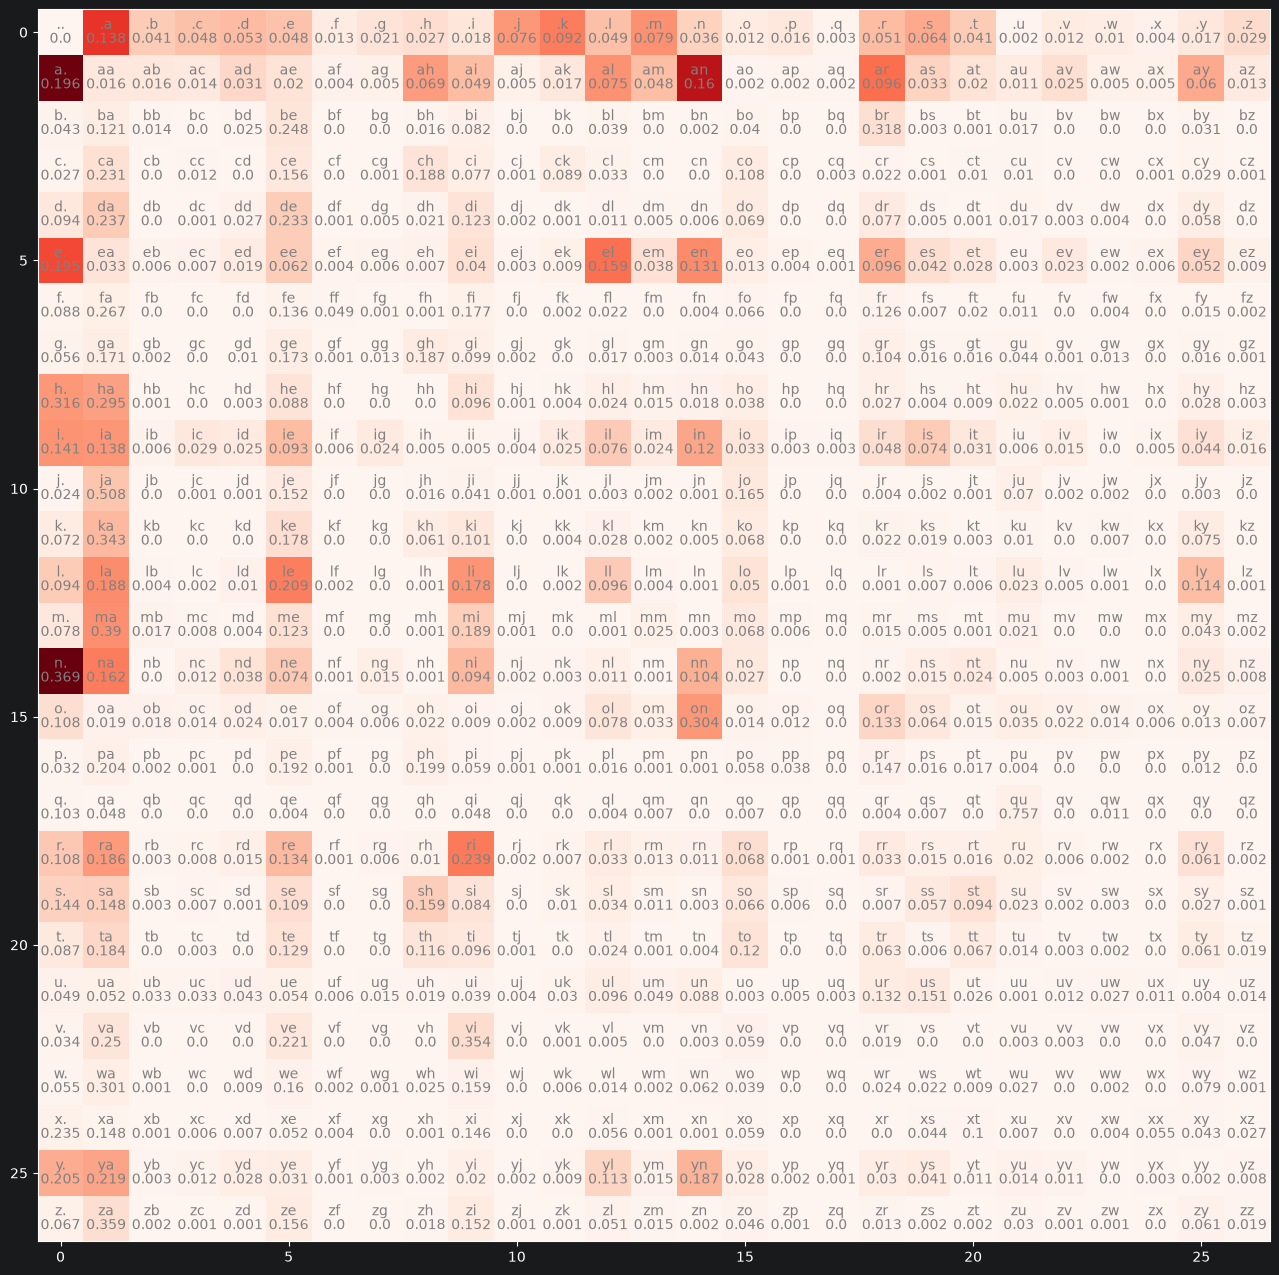

In [6]:
itos = {i: s for s, i in stoi.items()}
plt.figure(figsize = (16,16))
plt.imshow(N, cmap = 'Reds')
for i in range(27):
    p = N[i].float()
    p = p / p.sum()
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = 'gray')
        plt.text(j, i, round(p[j].item(), 3), ha = "center", va = "top", color = 'gray')
plt.axis('on')
plt.show()

In [7]:
p = N[0].float()
p = p / p.sum()
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
itos[ix]

'c'

In [31]:
P = (N+1).float()
P /= P.sum(1, keepdim = True)
P

tensor([[3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
         1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
         4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
         5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
         4.2109e-03, 1.6719e-02, 2.9008e-02],
        [1.9583e-01, 1.6425e-02, 1.5983e-02, 1.3889e-02, 3.0756e-02, 2.0435e-02,
         3.9809e-03, 4.9835e-03, 6.8796e-02, 4.8685e-02, 5.1899e-03, 1.6779e-02,
         7.4575e-02, 4.8213e-02, 1.6039e-01, 1.8872e-03, 2.4475e-03, 1.7988e-03,
         9.6279e-02, 3.2997e-02, 2.0288e-02, 1.1264e-02, 2.4623e-02, 4.7771e-03,
         5.3963e-03, 6.0480e-02, 1.2857e-02],
        [4.3039e-02, 1.2051e-01, 1.4596e-02, 7.4850e-04, 2.4701e-02, 2.4551e-01,
         3.7425e-04, 3.7425e-04, 1.5719e-02, 8.1587e-02, 7.4850e-04, 3.7425e-04,
         3.8922e-02, 3.7425e-04, 1.8713e-03, 3.9671e-02, 3.7425e-04, 3.7425e-04,
         3.1549e-

In [32]:
ix = 0
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    out = []
    while True:
        p = P[ix]
        # p = N[ix].float()
        # p = p / p.sum()
        ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        # print(itos[ix])
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.
x.
al.
kal.
thavazeeromysos.
laitenimieegariseriyen.
k.
illeleldole.
meenisammigama.
mmin.
asharin.
alcalar.
jayn.
asaz.
selanely.
chay.
rana.
ai.
yviamisashougen.
l.
beyncaro.
allan.
annutetoradrilia.
rddeman.


In [33]:
for i in range(27):
    print(N[:, i].sum(), N[i, :].sum())

tensor(32033) tensor(32033)
tensor(33885) tensor(33885)
tensor(2645) tensor(2645)
tensor(3532) tensor(3532)
tensor(5496) tensor(5496)
tensor(20423) tensor(20423)
tensor(905) tensor(905)
tensor(1927) tensor(1927)
tensor(7616) tensor(7616)
tensor(17701) tensor(17701)
tensor(2900) tensor(2900)
tensor(5040) tensor(5040)
tensor(13958) tensor(13958)
tensor(6642) tensor(6642)
tensor(18327) tensor(18327)
tensor(7934) tensor(7934)
tensor(1026) tensor(1026)
tensor(272) tensor(272)
tensor(12700) tensor(12700)
tensor(8106) tensor(8106)
tensor(5570) tensor(5570)
tensor(3135) tensor(3135)
tensor(2573) tensor(2573)
tensor(929) tensor(929)
tensor(697) tensor(697)
tensor(9776) tensor(9776)
tensor(2398) tensor(2398)


In [36]:
log_likelihood = 0.0
n = 0
for w in ["ctling"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]
        prob = P[index1, index2]
        logprob = torch.log(P[index1, index2])
        log_likelihood += logprob
        n += 1
        # N[index1][index2] += 1
        print(f"{ch1}{ch2}: {prob: .4f} {logprob: .4f}")
nll = -log_likelihood
print(f"{log_likelihood=}\n{nll=}\nnll/n={nll/n}")

.c:  0.0481 -3.0339
ct:  0.0101 -4.5937
tl:  0.0241 -3.7247
li:  0.1774 -1.7293
in:  0.1200 -2.1204
ng:  0.0149 -4.2045
g.:  0.0558 -2.8863
log_likelihood=tensor(-22.2928)
nll=tensor(22.2928)
nll/n=3.1846892833709717


In [41]:
# Create the training set of bigrams (x, y)
xs, ys = [], [] # xs for inputs, and ys for targets.

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]

        xs.append(index1)
        ys.append(index2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
xs

tensor([ 0,  5, 13, 13,  1])

In [55]:
import torch.nn.functional as F
# data type must be noticed well.
xenc = F.one_hot(xs, num_classes = 27).float() # xenc for x encoded
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [71]:
W = torch.randn((27, 27))
logits = xenc @ W
counts = logits.exp() # equivalent N
probs  = counts / counts.sum(1, keepdim = True)
probs

tensor([[0.0482, 0.0166, 0.0087, 0.0767, 0.0066, 0.0065, 0.0235, 0.0589, 0.0102,
         0.0045, 0.0110, 0.0139, 0.0587, 0.0017, 0.0058, 0.0285, 0.0847, 0.0711,
         0.1676, 0.1250, 0.0073, 0.0079, 0.0088, 0.0112, 0.0953, 0.0199, 0.0213],
        [0.0042, 0.1221, 0.0286, 0.0209, 0.0041, 0.0148, 0.0256, 0.0156, 0.0077,
         0.0143, 0.0965, 0.0246, 0.0072, 0.0244, 0.0875, 0.0896, 0.0170, 0.0212,
         0.0640, 0.1132, 0.0232, 0.0136, 0.0775, 0.0151, 0.0144, 0.0238, 0.0295],
        [0.0136, 0.0058, 0.0274, 0.0264, 0.0659, 0.0133, 0.0202, 0.0221, 0.0189,
         0.1212, 0.0184, 0.1278, 0.0034, 0.1055, 0.0086, 0.0500, 0.0140, 0.0338,
         0.0092, 0.0207, 0.0364, 0.0310, 0.0173, 0.0349, 0.0044, 0.0127, 0.1371],
        [0.0136, 0.0058, 0.0274, 0.0264, 0.0659, 0.0133, 0.0202, 0.0221, 0.0189,
         0.1212, 0.0184, 0.1278, 0.0034, 0.1055, 0.0086, 0.0500, 0.0140, 0.0338,
         0.0092, 0.0207, 0.0364, 0.0310, 0.0173, 0.0349, 0.0044, 0.0127, 0.1371],
        [0.0241, 0.1047,

##### Now we're summarizing.
---

In [72]:
# SUMMARY --------------------------------->>>>
print("xs: ", xs)
print("ys: ", ys)

xs:  tensor([ 0,  5, 13, 13,  1])
ys:  tensor([ 5, 13, 13,  1,  0])


In [104]:
g      = torch.Generator().manual_seed(2147483647)
W      = torch.randn((27, 27), generator = g, requires_grad = True)

In [113]:
# This Module is equivalent to forward pass.
xenc   = F.one_hot(xs, num_classes = 27).float()
logits = xenc @ W

# These two lines together are called softmax
counts = logits.exp()
probs  = counts / counts.sum(1, keepdim = True)

loss   = -probs[torch.arange(5), ys].log().mean()

##### Things are going to be identical with micrograd.
---

In [114]:
W.grad = None # a way to gradzero
loss.backward()

In [115]:
W.data += -0.1 * W.grad

In [116]:
loss.item()

3.5698916912078857

##### Final
---

In [140]:
# Final ----------------- >>>>>
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]

        xs.append(index1)
        ys.append(index2)

xs  = torch.tensor(xs)
ys  = torch.tensor(ys)
num = xs.nelement()
print("number of examples: ", num)

g      = torch.Generator().manual_seed(2147483647)
W      = torch.randn((27, 27), generator = g, requires_grad = True)

number of examples:  228146


In [147]:
for k in range(100):
    # This Module is equivalent to forward pass.
    xenc   = F.one_hot(xs, num_classes = 27).float()
    logits = xenc @ W
    # These two lines together are called softmax
    counts = logits.exp()
    probs  = counts / counts.sum(1, keepdim = True)
    loss   = -probs[torch.arange(num), ys].log().mean()

    print(f"loss currently: {loss.item()}")

    W.grad = None # a way to gradzero
    loss.backward()
    W.data += -10 * W.grad

loss currently: 2.4601616859436035
loss currently: 2.4601564407348633
loss currently: 2.460151433944702
loss currently: 2.460146188735962
loss currently: 2.4601409435272217
loss currently: 2.4601356983184814
loss currently: 2.460130453109741
loss currently: 2.460124969482422
loss currently: 2.4601197242736816
loss currently: 2.4601149559020996
loss currently: 2.4601097106933594
loss currently: 2.460104465484619
loss currently: 2.460099220275879
loss currently: 2.4600939750671387
loss currently: 2.4600884914398193
loss currently: 2.4600837230682373
loss currently: 2.460078477859497
loss currently: 2.460073232650757
loss currently: 2.4600682258605957
loss currently: 2.4600632190704346
loss currently: 2.4600579738616943
loss currently: 2.460052967071533
loss currently: 2.460047721862793
loss currently: 2.4600424766540527
loss currently: 2.4600377082824707
loss currently: 2.4600324630737305
loss currently: 2.4600274562835693
loss currently: 2.460022211074829
loss currently: 2.4600172042846

In [150]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    out = []
    ix  = 0
    while True:
        # p = P[ix]
        # p = N[ix].float()
        # p = p / p.sum()
        xenc   = F.one_hot(torch.tensor([ix]), num_classes = 27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim = True)
        ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        # print(itos[ix])
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
eniaviyny.
fobspehinivenvtahlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.
x.
al.
kal.
thavazeeromysos.
laitenimieegariseriyen.
k.
illeleldole.
meenisammigama.
mmin.
asharficalisah.
ciayn.
asaza.
elanely.
chay.
rana.
ai.
yviamisashougen.
l.
beyncaro.
allan.
annutetoradrilia.
rddemkaha.
cahiahevara.


![image](images/makemore_contrast.png "nn-contrast")